In [1]:
import os, gc, re, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pandas.api.types import union_categoricals
from scipy import sparse
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve)
from sklearn.model_selection import train_test_split

try:
    from IPython.display import display
except ImportError:          # allows the code to run as a plain script too
    display = print

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

import tensorflow as tf_
from tensorflow import keras
from tensorflow.keras import layers
print('TensorFlow', tf_.__version__)

TensorFlow 2.21.0


In [2]:
MODEL_NAME = "LSTM"
MODEL_SLUG = "lstm"
RANDOM_STATE = 42
TRAIN_FRACTION = 0.80                 # 80 % train / 20 % test
SPLIT_MODE = "chronological"          # "chronological" (sort by Timestamp: first 80 % = train, last 20 % = test)  or  "random" (stratified)
THRESHOLDS = [0.50, 0.40, 0.30, 0.20, 0.10]
TARGET_PRECISION = 0.20               # project goal
TARGET_RECALL = 0.80                  # project goal
DEBUG_NROWS = None                    # None = ALL rows. e.g. 300_000 only for a quick smoke test
SEQUENCE_LENGTH = 10                # transactions per sequence
BATCH_SIZE = 2048
EPOCHS = 5
LSTM_UNITS = 64
LEARNING_RATE = 1e-3
PATIENCE = 2

keras.utils.set_random_seed(RANDOM_STATE)

def find_project_root():
    """Walk upwards from the notebook's folder until we find the AML-GNN-Project root
    (the folder that contains data/processed). Works from notebooks/ or models/."""
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "data" / "processed").is_dir():
            return cand
    raise FileNotFoundError("Could not find a folder containing data/processed. "
                            "Open the notebook from inside AML-GNN-Project or set PROJECT_ROOT manually.")

PROJECT_ROOT = find_project_root()          # e.g. PROJECT_ROOT = Path(r"C:/.../AML-GNN-Project")
DATA_RAW       = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR     = PROJECT_ROOT / "models"
OUTPUTS_DIR    = PROJECT_ROOT / "outputs"
RESULTS_DIR    = PROJECT_ROOT / "results"
for d in (MODELS_DIR, OUTPUTS_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

PATH_TRANSACTIONS      = DATA_PROCESSED / "transactions.csv"
PATH_TX_FEATURES       = DATA_PROCESSED / "transaction_features.csv"
PATH_ACCOUNT_BEHAVIOUR = DATA_PROCESSED / "account_behaviour.csv"
PATH_TEMPORAL          = DATA_PROCESSED / "temporal_features.csv"
PATH_GRAPH             = DATA_PROCESSED / "graph_features.csv"
PATH_BANKS             = DATA_PROCESSED / "banks.csv"
PATH_ACCOUNTS          = DATA_PROCESSED / "accounts.csv"
PATH_PATTERNS          = DATA_RAW / "LI-Small_Patterns.txt"

print("Project root :", PROJECT_ROOT)
for p in (PATH_TRANSACTIONS, PATH_TX_FEATURES, PATH_ACCOUNT_BEHAVIOUR, PATH_TEMPORAL, PATH_GRAPH, PATH_BANKS, PATH_ACCOUNTS):
    print(f"  {'OK     ' if p.exists() else 'MISSING'} {p.relative_to(PROJECT_ROOT)}")

Project root : E:\AML-GNN-Project
  OK      data\processed\transactions.csv
  OK      data\processed\transaction_features.csv
  OK      data\processed\account_behaviour.csv
  OK      data\processed\temporal_features.csv
  OK      data\processed\graph_features.csv
  OK      data\processed\banks.csv
  OK      data\processed\accounts.csv


In [3]:
# Which columns are taken from which processed table. Nothing is created - these are the columns of the files.
TX_COLS = ["Transaction ID", "Timestamp", "From Bank", "To Bank", "Amount Received", "Receiving Currency",
           "Amount Paid", "Payment Currency", "Payment Format", "Is Laundering"]
TF_COLS = ["Transaction ID", "Is Currency Same", "Transaction Hour", "Day of Week",
           "Sender Bank Country", "Receiver Bank Country", "Is Cross Border"]
AB_COLS = ["Incoming Transaction Count", "Outgoing Transaction Count", "Total Incoming Amount", "Total Outgoing Amount",
           "Average Incoming Amount", "Average Outgoing Amount", "Unique Senders", "Unique Receivers"]
GF_COLS = ["Sender In Degree", "Sender Out Degree", "Sender PageRank", "Receiver In Degree", "Receiver Out Degree", "Receiver PageRank",
           "Sender Triangle Count", "Receiver Triangle Count", "Sender Community Size", "Receiver Community Size"]
TP_COLS = ["Transactions Last 1 Hour", "Transactions Last 24 Hours", "Transactions Last 7 Days", "Amount Last 24 Hours", "Time Since Previous Transaction"]
BANK_COLS = ["Sender Transaction Count", "Receiver Transaction Count"]      # banks.csv, joined on Bank ID
# NOT used as model inputs (identifiers / text / the target): Account IDs, Bank IDs, Community IDs, Entity names, Account numbers, Country Pair.

In [4]:
t0 = time.time()
tx = pd.read_csv(PATH_TRANSACTIONS, usecols=["Transaction ID", "Timestamp", "Amount Received", "Amount Paid", "Payment Format", "Is Laundering"], nrows=DEBUG_NROWS,
                 dtype={"Transaction ID": "int32", "Timestamp": "category", "Payment Format": "category", "Is Laundering": "int8"})
tf = pd.read_csv(PATH_TX_FEATURES, usecols=["Transaction ID", "Sender Account ID", "Is Currency Same", "Transaction Hour", "Day of Week", "Is Cross Border"], nrows=DEBUG_NROWS,
                 dtype={"Transaction ID": "int32", "Sender Account ID": "category", "Is Currency Same": "category", "Is Cross Border": "category",
                        "Transaction Hour": "float32", "Day of Week": "float32"})
tp = pd.read_csv(PATH_TEMPORAL, usecols=["Transaction ID"] + TP_COLS, dtype={"Transaction ID": "int32", **{c: "float32" for c in TP_COLS}}, nrows=DEBUG_NROWS)
print(f"transactions.csv         : {tx.shape[0]:,} rows | transaction_features.csv: {tf.shape[0]:,} rows | temporal_features.csv: {tp.shape[0]:,} rows ({time.time() - t0:.1f}s)")
n_tx = len(tx)
for nm, t in [("transaction_features", tf), ("temporal_features", tp)]:
    assert t["Transaction ID"].is_unique
    tx = tx.merge(t, on="Transaction ID", how="left", validate="one_to_one")
    assert len(tx) == n_tx
    print(f"+ {nm:<22} -> {tx.shape[0]:,} rows x {tx.shape[1]} columns")
del tf, tp
gc.collect()

transactions.csv         : 6,924,049 rows | transaction_features.csv: 6,924,049 rows | temporal_features.csv: 6,924,049 rows (17.1s)
+ transaction_features   -> 6,924,049 rows x 11 columns
+ temporal_features      -> 6,924,049 rows x 16 columns


0

In [5]:
# ---- Timestamp -> numbers (only used to order the data in time; it is not a model input) ----
def parse_timestamp_column(col):
    col = col.astype("category")
    cats = pd.Series(col.cat.categories.astype(str))
    for fmt in ["%d-%m-%Y %H:%M", "%Y/%m/%d %H:%M", "%Y-%m-%d %H:%M", "%d/%m/%Y %H:%M", "%m/%d/%Y %H:%M"]:
        parsed = pd.to_datetime(cats, format=fmt, errors="coerce")
        if parsed.notna().mean() > 0.999:
            print("Timestamp format:", fmt)
            break
    else:
        raise ValueError("Unknown Timestamp format")
    secs = (parsed - pd.Timestamp("1970-01-01")).dt.total_seconds().to_numpy()
    return np.append(secs, np.nan)[col.cat.codes.to_numpy()]

ts_abs = parse_timestamp_column(tx["Timestamp"])
bad = np.isnan(ts_abs)
print(f"Rows with an unreadable Timestamp (dropped): {int(bad.sum()):,}")
tx = tx.loc[~bad].drop(columns=["Timestamp"]).reset_index(drop=True)
tx["ts_abs"] = ts_abs[~bad].astype(np.int64)
del ts_abs, bad

# ---- TRUE/FALSE text columns -> 1/0 ----
def binary_from_category(s):
    s = s.astype("category")
    truthy = {"TRUE", "1", "1.0", "YES", "T", "Y"}
    lookup = np.array([1 if str(c).strip().upper() in truthy else 0 for c in s.cat.categories] + [-1], dtype=np.float32)
    out = lookup[s.cat.codes.to_numpy()]
    out[s.cat.codes.to_numpy() < 0] = np.nan
    return out
for c in ["Is Currency Same", "Is Cross Border"]:
    tx[c] = binary_from_category(tx[c])

# ---- chronological order (needed for the time-based split) ----
tx = tx.sort_values(["ts_abs", "Transaction ID"], kind="stable").reset_index(drop=True)
ts_abs = tx["ts_abs"].to_numpy()
print("Data spans:", pd.to_datetime(ts_abs[0], unit="s"), "->", pd.to_datetime(ts_abs[-1], unit="s"))

# ---- Transaction Hour / Day of Week: use the file's values; only if a value is blank, take it from this row's Timestamp ----
hour_ts = ((ts_abs // 3600) % 24).astype(np.float32)
dow_ts = (((ts_abs // 86400) + 3) % 7).astype(np.float32)          # 0 = Monday
for col, derived in (("Transaction Hour", hour_ts), ("Day of Week", dow_ts)):
    n_blank = int(tx[col].isna().sum())
    print(f"{col}: {n_blank:,} blank values in the file ({n_blank / len(tx):.1%})")
    if n_blank:
        print(f"   -> blanks filled from the transaction's own Timestamp")
        tx[col] = tx[col].fillna(pd.Series(derived))
del hour_ts, dow_ts
gc.collect()

# ---- missing values per column ----
miss = tx.isna().sum()
print("\nColumns with missing values (these are filled with -1 in the model matrix):")
print(miss[miss > 0].to_string() if (miss > 0).any() else "none")

Timestamp format: %Y/%m/%d %H:%M
Rows with an unreadable Timestamp (dropped): 0
Data spans: 2022-09-01 00:00:00 -> 2022-09-17 15:28:00
Transaction Hour: 6,924,049 blank values in the file (100.0%)
   -> blanks filled from the transaction's own Timestamp
Day of Week: 6,924,049 blank values in the file (100.0%)
   -> blanks filled from the transaction's own Timestamp

Columns with missing values (these are filled with -1 in the model matrix):
Time Since Previous Transaction    681283


In [6]:
day = ts_abs // 86400
u, inv, cnt = np.unique(day, return_inverse=True, return_counts=True)
pos = np.bincount(inv.ravel(), weights=tx["Is Laundering"].to_numpy(), minlength=len(u)).astype(int)
daily = pd.DataFrame({"Date": pd.to_datetime(u * 86400, unit="s").date, "Rows": cnt, "Laundering": pos})
daily["Laundering %"] = 100 * daily["Laundering"] / daily["Rows"]
print("Rows and laundering cases per day (information only - nothing is removed):")
with pd.option_context("display.float_format", lambda v: f"{v:,.3f}"):
    display(daily)

Rows and laundering cases per day (information only - nothing is removed):


,Date,Rows,Laundering,Laundering %
0,2022-09-01,1524807,310,0.020
1,2022-09-02,1027758,350,0.034
2,2022-09-03,283326,292,0.103
3,2022-09-04,282476,291,0.103
4,2022-09-05,657397,370,0.056
5,2022-09-06,657170,380,0.058
6,2022-09-07,658504,368,0.056
7,2022-09-08,657938,402,0.061
8,2022-09-09,891573,367,0.041
9,2022-09-10,282877,301,0.106


In [7]:
y = tx["Is Laundering"].to_numpy(np.int8)
tx_ids = tx["Transaction ID"].to_numpy(np.int64)
n = len(y)
cut = int(TRAIN_FRACTION * n)

if SPLIT_MODE == "chronological":
    train_idx, test_idx = np.arange(0, cut), np.arange(cut, n)      # data is already sorted by time: past = train, future = test
else:
    train_idx, test_idx = train_test_split(np.arange(n), test_size=1 - TRAIN_FRACTION, stratify=y, random_state=RANDOM_STATE)
    train_idx, test_idx = np.sort(train_idx), np.sort(test_idx)

if y[train_idx].sum() == 0 or y[test_idx].sum() == 0:
    print("!" * 80)
    print("WARNING: the chronological split leaves a set without laundering examples -> falling back to a stratified random 80/20 split.")
    print("!" * 80)
    SPLIT_MODE = "random (fallback)"
    train_idx, test_idx = train_test_split(np.arange(n), test_size=1 - TRAIN_FRACTION, stratify=y, random_state=RANDOM_STATE)
    train_idx, test_idx = np.sort(train_idx), np.sort(test_idx)

print(f"Split mode: {SPLIT_MODE}")
print(f"Train rows: {len(train_idx):,} | Test rows: {len(test_idx):,}   (ALL {n:,} rows are used - nothing sampled or removed)")
print(f"Train laundering: {int(y[train_idx].sum()):,} | Train normal: {int((y[train_idx] == 0).sum()):,} | Train laundering %: {100 * y[train_idx].mean():.4f}")
print(f"Test  laundering: {int(y[test_idx].sum()):,} | Test  normal: {int((y[test_idx] == 0).sum()):,} | Test  laundering %: {100 * y[test_idx].mean():.4f}")
if SPLIT_MODE == "chronological":
    print("Train period:", pd.to_datetime(ts_abs[train_idx[0]], unit="s"), "->", pd.to_datetime(ts_abs[train_idx[-1]], unit="s"))
    print("Test  period:", pd.to_datetime(ts_abs[test_idx[0]], unit="s"), "->", pd.to_datetime(ts_abs[test_idx[-1]], unit="s"))

Split mode: chronological
Train rows: 5,539,239 | Test rows: 1,384,810   (ALL 6,924,049 rows are used - nothing sampled or removed)
Train laundering: 2,640 | Train normal: 5,536,599 | Train laundering %: 0.0477
Test  laundering: 925 | Test  normal: 1,383,885 | Test  laundering %: 0.0668
Train period: 2022-09-01 00:00:00 -> 2022-09-08 16:06:00
Test  period: 2022-09-08 16:06:00 -> 2022-09-17 15:28:00


In [8]:
# per-timestep features, all taken from the table columns (log / sin-cos are just rescalings of those columns)
miss_sender = int(tx["Sender Account ID"].isna().sum())
assert miss_sender == 0, f"{miss_sender} rows have no Sender Account ID"
sender_code = tx["Sender Account ID"].cat.codes.to_numpy(np.int64)       # integer code per sender account (used only to group sequences)

hr, dw = tx["Transaction Hour"].to_numpy(np.float64), tx["Day of Week"].to_numpy(np.float64)
cont = pd.DataFrame({
    "Amount Received (log1p)": np.log1p(tx["Amount Received"].clip(lower=0)), "Amount Paid (log1p)": np.log1p(tx["Amount Paid"].clip(lower=0)),
    "Transactions Last 1 Hour (log1p)": np.log1p(tx["Transactions Last 1 Hour"].fillna(0).clip(lower=0)),
    "Transactions Last 24 Hours (log1p)": np.log1p(tx["Transactions Last 24 Hours"].fillna(0).clip(lower=0)),
    "Transactions Last 7 Days (log1p)": np.log1p(tx["Transactions Last 7 Days"].fillna(0).clip(lower=0)),
    "Amount Last 24 Hours (log1p)": np.log1p(tx["Amount Last 24 Hours"].fillna(0).clip(lower=0)),
    "Time Since Previous Transaction (log1p)": np.log1p(tx["Time Since Previous Transaction"].fillna(0).clip(lower=0)),
    "Hour sin": np.sin(2 * np.pi * hr / 24), "Hour cos": np.cos(2 * np.pi * hr / 24),
    "Day of Week sin": np.sin(2 * np.pi * dw / 7), "Day of Week cos": np.cos(2 * np.pi * dw / 7),
}).astype(np.float32).fillna(0)
CONT_COLS = list(cont.columns)
bin_df = pd.DataFrame({"Is Currency Same": tx["Is Currency Same"].fillna(0), "Is Cross Border": tx["Is Cross Border"].fillna(0),
                       "Time Since Previous is blank (first txn)": tx["Time Since Previous Transaction"].isna().astype(np.float32)}).astype(np.float32)
fmt_levels = sorted(tx["Payment Format"].iloc[train_idx].dropna().astype(str).unique())
fmt_df = pd.get_dummies(tx["Payment Format"].astype(str).astype("category").cat.set_categories(fmt_levels), prefix="Payment Format", dtype=np.float32)

# standardise continuous columns with TRAIN-row statistics only
mu = cont.iloc[train_idx].mean().to_numpy(np.float64)
sd = cont.iloc[train_idx].std().replace(0, 1).to_numpy(np.float64)
cont_scaled = ((cont.to_numpy(np.float64) - mu) / sd).astype(np.float32)
FEATURE_NAMES = CONT_COLS + list(bin_df.columns) + list(fmt_df.columns)
F = np.hstack([cont_scaled, bin_df.to_numpy(np.float32), fmt_df.to_numpy(np.float32)]).astype(np.float32)
N_FEATURES = F.shape[1] + 1
print(f"Per-transaction feature matrix F: {F.shape} | LSTM input per timestep: {N_FEATURES} (incl. padding flag)")
print("Features:", FEATURE_NAMES)
del cont, cont_scaled, bin_df, fmt_df, hr, dw
tx = tx[["Transaction ID"]]
gc.collect()

Per-transaction feature matrix F: (6924049, 21) | LSTM input per timestep: 22 (incl. padding flag)
Features: ['Amount Received (log1p)', 'Amount Paid (log1p)', 'Transactions Last 1 Hour (log1p)', 'Transactions Last 24 Hours (log1p)', 'Transactions Last 7 Days (log1p)', 'Amount Last 24 Hours (log1p)', 'Time Since Previous Transaction (log1p)', 'Hour sin', 'Hour cos', 'Day of Week sin', 'Day of Week cos', 'Is Currency Same', 'Is Cross Border', 'Time Since Previous is blank (first txn)', 'Payment Format_ACH', 'Payment Format_Bitcoin', 'Payment Format_Cash', 'Payment Format_Cheque', 'Payment Format_Credit Card', 'Payment Format_Reinvestment', 'Payment Format_Wire']


0

In [9]:
# ---- Sequence construction ----------------------------------------------------------------------------
# For each transaction t of sender account A:  sequence = the last SEQUENCE_LENGTH transactions of A, ending WITH t.
# The label is the label of t (the LAST step). Earlier steps contribute features only. Short histories are zero-padded
# (+ a padding flag). Rows are in time order, so a stable sort by sender gives every account's history in time order.
order = np.argsort(sender_code, kind="stable")
pos_in_order = np.empty(len(order), dtype=np.int64); pos_in_order[order] = np.arange(len(order))
sorted_sender = sender_code[order]
block_start = np.searchsorted(sorted_sender, sorted_sender, side="left")[pos_in_order]
OFFSETS = np.arange(-SEQUENCE_LENGTH + 1, 1)
del sorted_sender
BaseSeq = getattr(keras.utils, "PyDataset", None) or keras.utils.Sequence


class SequenceBatches(BaseSeq):
    """Builds mini-batches on the fly so the full 3-D tensor never has to fit in memory."""
    def __init__(self, target_ids, labels=True, class_weights=None, batch_size=2048, shuffle=False, seed=42):
        super().__init__()
        self.ids = np.asarray(target_ids).copy(); self.labels = labels; self.cw = class_weights
        self.batch_size = batch_size; self.shuffle = shuffle; self.rng = np.random.default_rng(seed)
        if shuffle: self.rng.shuffle(self.ids)

    def __len__(self):
        return int(np.ceil(len(self.ids) / self.batch_size))

    def _gather(self, ids):
        idx = pos_in_order[ids][:, None] + OFFSETS[None, :]
        valid = idx >= block_start[ids][:, None]
        return order[np.clip(idx, 0, None)], valid

    def __getitem__(self, i):
        ids = self.ids[i * self.batch_size:(i + 1) * self.batch_size]
        rows, valid = self._gather(ids)
        x = np.concatenate([F[rows] * valid[:, :, None], valid[:, :, None].astype(np.float32)], axis=2)
        if not self.labels:
            return x
        yy = y[ids].astype(np.float32)
        return x, yy, np.where(yy == 1, self.cw[1], self.cw[0]).astype(np.float32)

    def on_epoch_end(self):
        if self.shuffle: self.rng.shuffle(self.ids)


# sanity check: a sequence never contains a later transaction or another account
rs = np.random.default_rng(RANDOM_STATE)
chk = np.sort(rs.choice(test_idx, size=min(3000, len(test_idx)), replace=False))
rows_c, valid_c = SequenceBatches(chk, labels=False)._gather(chk)
tgt = np.broadcast_to(chk[:, None], rows_c.shape)
assert (rows_c[:, -1] == chk).all() and (rows_c[valid_c] <= tgt[valid_c]).all()
assert (sender_code[rows_c][valid_c] == np.broadcast_to(sender_code[chk][:, None], rows_c.shape)[valid_c]).all()
print("Sequence check passed: last step = the transaction being predicted, no later transactions, one sender account per sequence.")

Sequence check passed: last step = the transaction being predicted, no later transactions, one sender account per sequence.


In [10]:
def evaluate_scores(y_true, score, threshold=0.50):
    """Binary metrics at a threshold + ranking metrics (ROC-AUC, PR-AUC) that do not depend on the threshold."""
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score, dtype=float)
    pred = (score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    both = len(np.unique(y_true)) == 2
    return {
        "Threshold": float(threshold),
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1-Score": f1_score(y_true, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, score) if both else np.nan,
        "PR-AUC": average_precision_score(y_true, score) if both else np.nan,
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }


def best_f1_threshold(y_true, score):
    """Threshold maximising F1 - to be computed on VALIDATION data only (never on the test set)."""
    p, r, t = precision_recall_curve(y_true, score)
    f1 = 2 * p[:-1] * r[:-1] / np.clip(p[:-1] + r[:-1], 1e-12, None)
    return float(t[int(np.argmax(f1))]) if len(t) else 0.5


def save_confusion_matrix(y_true, pred, path, title):
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}\n({norm[i, j]:.1%} of row)", ha="center", va="center",
                    color="white" if norm[i, j] > 0.5 else "black")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Normal", "Pred Laundering"]); ax.set_yticklabels(["Actual Normal", "Actual Laundering"])
    ax.set_title(title); fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()


def save_roc_curve(y_true, score, path, title):
    fpr, tpr, _ = roc_curve(y_true, score)
    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    ax.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_true, score):.4f}")
    ax.plot([0, 1], [0, 1], "--", color="grey", label="Random guess")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate (Recall)")
    ax.set_title(title); ax.legend(); fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()


def save_pr_curve(y_true, score, path, title):
    p, r, _ = precision_recall_curve(y_true, score)
    prevalence = float(np.mean(y_true))
    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    ax.plot(r, p, label=f"PR-AUC (AP) = {average_precision_score(y_true, score):.4f}")
    ax.axhline(prevalence, ls="--", color="grey", label=f"No-skill baseline = {prevalence:.5f}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title(title); ax.legend()
    fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()


def save_risk_distribution(y_true, score, path, title, threshold=0.50):
    y_true = np.asarray(y_true)
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    bins = np.linspace(0, 1, 51)
    ax.hist(score[y_true == 0], bins=bins, alpha=0.65, label="Actual normal", color="tab:blue")
    ax.hist(score[y_true == 1], bins=bins, alpha=0.75, label="Actual laundering", color="tab:red")
    ax.axvline(threshold, color="black", ls="--", label=f"Threshold = {threshold:.2f}")
    ax.set_yscale("log"); ax.set_xlabel("AML Risk Score  =  P(Is Laundering = 1)"); ax.set_ylabel("Number of transactions (log scale)")
    ax.set_title(title); ax.legend(); fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()


def save_feature_importance(names, values, path, title, top=25):
    imp = pd.Series(values, index=names).sort_values(ascending=False).head(top)[::-1]
    fig, ax = plt.subplots(figsize=(8, 0.33 * len(imp) + 1.5))
    ax.barh(imp.index, imp.values, color="tab:green")
    ax.set_title(title); ax.set_xlabel("Importance"); fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()
    return imp[::-1]


def predict_in_chunks(model, X, chunk=200_000):
    """predict_proba(...)[:, 1] in chunks to keep memory low."""
    out = np.empty(len(X), dtype=np.float32)
    for i in range(0, len(X), chunk):
        out[i:i + chunk] = model.predict_proba(X.iloc[i:i + chunk])[:, 1]
    return out



# ---------- threshold study (target: precision >= 20 %, recall >= 80 %) ----------
# 0.50 / 0.40 / 0.30 / 0.20 / 0.10 were requested; the other values are extras (RF / LR scores can sit far from 0.5).
SWEEP_THRESHOLDS = [0.90, 0.70, 0.50, 0.40, 0.30, 0.20, 0.10, 0.05, 0.02]


def threshold_sweep(y_true, score, thresholds=SWEEP_THRESHOLDS):
    rows = []
    for t in thresholds:
        m = evaluate_scores(y_true, score, t)
        rows.append({"Threshold": t, "TP": m["TP"], "FP": m["FP"], "FN": m["FN"], "TN": m["TN"],
                     "Precision": m["Precision"], "Recall": m["Recall"], "F1-Score": m["F1-Score"],
                     "Flagged": m["TP"] + m["FP"],
                     f"Meets P>={TARGET_PRECISION:.0%} & R>={TARGET_RECALL:.0%}": bool(m["Precision"] >= TARGET_PRECISION and m["Recall"] >= TARGET_RECALL)})
    return pd.DataFrame(rows)


def pick_threshold_for_recall(y_val, s_val, min_recall=None):
    """Highest threshold whose VALIDATION recall is still >= min_recall (= best precision that keeps the recall target).
    Returns None if no threshold reaches the recall target on validation."""
    min_recall = TARGET_RECALL if min_recall is None else min_recall
    p, r, t = precision_recall_curve(y_val, s_val)
    ok = np.where(r[:-1] >= min_recall)[0]
    return float(t[ok[-1]]) if len(ok) else None


def subset_metrics(y_true, score, masks, threshold):
    rows = []
    for name, m in masks.items():
        if m.sum() == 0:
            continue
        rows.append({"Subset": name, "Rows": int(m.sum()), "Laundering": int(y_true[m].sum()), **evaluate_scores(y_true[m], score[m], threshold)})
    return pd.DataFrame(rows)


def save_threshold_tradeoff(y_true, score, path, title):
    p, r, t = precision_recall_curve(y_true, score)
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    ax.plot(t, p[:-1], label="Precision"); ax.plot(t, r[:-1], label="Recall")
    ax.axhline(TARGET_PRECISION, ls="--", color="tab:blue", alpha=0.5, label=f"Target precision {TARGET_PRECISION:.0%}")
    ax.axhline(TARGET_RECALL, ls="--", color="tab:orange", alpha=0.5, label=f"Target recall {TARGET_RECALL:.0%}")
    ax.set_xlabel("Threshold on AML Risk Score"); ax.set_ylabel("Precision / Recall"); ax.set_title(title); ax.legend()
    fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()

all_metrics = []     # every metrics row is collected here and saved at the end

In [11]:
# Validation slice (for the loss curve and early stopping only): the LAST 10 % of the training rows in time order. The 20 % TEST part is not touched.
vcut = int(0.9 * len(train_idx))
fit_idx, val_idx = train_idx[:vcut], train_idx[vcut:]
n_pos_fit, n_neg_fit = int(y[fit_idx].sum()), int((y[fit_idx] == 0).sum())
CLASS_WEIGHTS = {0: (n_pos_fit + n_neg_fit) / (2.0 * n_neg_fit), 1: (n_pos_fit + n_neg_fit) / (2.0 * n_pos_fit)}   # from training rows only
print(f"Training sequences: {len(fit_idx):,} (laundering {n_pos_fit:,}) | validation sequences: {len(val_idx):,} (laundering {int(y[val_idx].sum()):,}) | test sequences: {len(test_idx):,}")
print(f"Class weights: normal = {CLASS_WEIGHTS[0]:.4f} | laundering = {CLASS_WEIGHTS[1]:.2f}")
train_batches = SequenceBatches(fit_idx, True, CLASS_WEIGHTS, BATCH_SIZE, shuffle=True, seed=RANDOM_STATE)
val_batches = SequenceBatches(val_idx, True, CLASS_WEIGHTS, BATCH_SIZE)

inputs = keras.Input(shape=(SEQUENCE_LENGTH, N_FEATURES))
x = layers.LSTM(LSTM_UNITS)(inputs)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs, name="aml_lstm")
model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE), loss="binary_crossentropy", metrics=[keras.metrics.AUC(name="pr_auc", curve="PR")])
model.summary()
callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)]
t0 = time.time()
history = model.fit(train_batches, validation_data=val_batches, epochs=EPOCHS, callbacks=callbacks, verbose=1)
print(f"Training finished in {(time.time() - t0) / 60:.1f} min")

Training sequences: 4,985,315 (laundering 2,314) | validation sequences: 553,924 (laundering 326) | test sequences: 1,384,810
Class weights: normal = 0.5002 | laundering = 1077.21


Model: "aml_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 22)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,385 (95.25 KB)

 Trainable params: 24,385 (95.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
2435/2435 ━━━━━━━━━━━━━━━━━━━━ 102s 41ms/step - loss: 0.3231 - pr_auc: 0.0084 - val_loss: 0.2633 - val_pr_auc: 0.0149
Epoch 2/5
2435/2435 ━━━━━━━━━━━━━━━━━━━━ 181s 74ms/step - loss: 0.2490 - pr_auc: 0.0152 - val_loss: 0.2548 - val_pr_auc: 0.0480
Epoch 3/5
2435/2435 ━━━━━━━━━━━━━━━━━━━━ 175s 72ms/step - loss: 0.2338 - pr_auc: 0.0236 - val_loss: 0.2661 - val_pr_auc: 0.0642
Epoch 4/5
2435/2435 ━━━━━━━━━━━━━━━━━━━━ 185s 76ms/step - loss: 0.2249 - pr_auc: 0.0331 - val_loss: 0.2388 - val_pr_auc: 0.1017
Epoch 5/5
2435/2435 ━━━━━━━━━━━━━━━━━━━━ 171s 63ms/step - loss: 0.2166 - pr_auc: 0.0366 - val_loss: 0.2434 - val_pr_auc: 0.0804
Training finished in 14.4 min


In [12]:
y_test = y[test_idx]
score_test = model.predict(SequenceBatches(test_idx, labels=False, batch_size=8192), verbose=1).ravel().astype(np.float32)   # AML Risk Score
pred_table = pd.DataFrame({"Transaction ID": tx_ids[test_idx], "Actual Is Laundering": y_test.astype(int),
                           "AML Risk Score": np.round(score_test, 6), "Predicted Label": (score_test >= 0.50).astype(int)})
print("First 10 test predictions:"); display(pred_table.head(10))
print("Top 10 highest AML Risk Scores:"); display(pred_table.sort_values("AML Risk Score", ascending=False).head(10))
print(f"Average risk score {score_test.mean():.4f} | highest {score_test.max():.4f}")

170/170 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step
First 10 test predictions:


,Transaction ID,Actual Is Laundering,AML Risk Score,Predicted Label
0,5544005,0,0.000997,0
1,5544098,0,0.001012,0
2,5544111,0,0.071765,0
3,5544124,0,0.001754,0
4,5544135,0,0.000089,0
5,5544152,0,0.867510,1
6,5544161,0,0.000600,0
7,5544184,0,0.753908,1
8,5544197,0,0.605066,1
9,5544206,0,0.757804,1


Top 10 highest AML Risk Scores:


,Transaction ID,Actual Is Laundering,AML Risk Score,Predicted Label
1384740,6890435,1,0.999972,1
1384727,4897740,1,0.999933,1
1384745,3593988,1,0.999928,1
1384753,6890437,1,0.999925,1
1384685,4897734,1,0.999917,1
1384618,5243412,1,0.999845,1
1384798,6049225,1,0.999802,1
1384711,4897736,1,0.999780,1
1384721,4897738,1,0.999771,1
1384742,3593986,1,0.999763,1


Average risk score 0.1587 | highest 1.0000


In [13]:
# ============================================================================================
# THRESHOLD STUDY  (cell 1 of 4): run thresholds 0.50, 0.40, 0.30, 0.20, 0.10 one after another
# Rule applied each time:  AML Risk Score >= threshold  ->  predicted laundering (1), else normal (0)
# ============================================================================================
THRESHOLDS = [0.50, 0.40, 0.30, 0.20, 0.10]
y_test = y[test_idx]                       # true labels of the (untouched) test set
threshold_rows = []

for thr in THRESHOLDS:
    pred = (score_test >= thr).astype(int)
    m = evaluate_scores(y_test, score_test, thr)           # Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, TN, FP, FN, TP
    m["Flagged"] = m["TP"] + m["FP"]
    m["Flagged % of test"] = 100 * m["Flagged"] / len(y_test)
    threshold_rows.append(m)

    print("=" * 78)
    print(f"{MODEL_NAME.upper()}  |  THRESHOLD = {thr:.2f}")
    print("=" * 78)
    print(f"TP (laundering caught)  : {m['TP']:,}")
    print(f"FP (normal flagged)     : {m['FP']:,}")
    print(f"FN (laundering missed)  : {m['FN']:,}")
    print(f"TN (normal passed)      : {m['TN']:,}")
    print(f"Transactions flagged    : {m['Flagged']:,}  ({m['Flagged % of test']:.2f}% of the test set)")
    print(f"Accuracy {m['Accuracy']:.4f} | Precision {m['Precision']:.4f} | Recall {m['Recall']:.4f} | "
          f"F1 {m['F1-Score']:.4f} | ROC-AUC {m['ROC-AUC']:.4f} | PR-AUC {m['PR-AUC']:.4f}")
    print(classification_report(y_test, pred, target_names=["Normal (0)", "Laundering (1)"], digits=4, zero_division=0))

LSTM  |  THRESHOLD = 0.50
TP (laundering caught)  : 911
FP (normal flagged)     : 246,160
FN (laundering missed)  : 14
TN (normal passed)      : 1,137,725
Transactions flagged    : 247,071  (17.84% of the test set)
Accuracy 0.8222 | Precision 0.0037 | Recall 0.9849 | F1 0.0073 | ROC-AUC 0.9626 | PR-AUC 0.1880
                precision    recall  f1-score   support

    Normal (0)     1.0000    0.8221    0.9024   1383885
Laundering (1)     0.0037    0.9849    0.0073       925

      accuracy                         0.8222   1384810
     macro avg     0.5018    0.9035    0.4549   1384810
  weighted avg     0.9993    0.8222    0.9018   1384810

LSTM  |  THRESHOLD = 0.40
TP (laundering caught)  : 912
FP (normal flagged)     : 259,157
FN (laundering missed)  : 13
TN (normal passed)      : 1,124,728
Transactions flagged    : 260,069  (18.78% of the test set)
Accuracy 0.8128 | Precision 0.0035 | Recall 0.9859 | F1 0.0070 | ROC-AUC 0.9626 | PR-AUC 0.1880
                precision    recall  f1

In [14]:
# ============================================================================================
# THRESHOLD STUDY (cell 2 of 4): comparison table
# ============================================================================================
thr_df = pd.DataFrame(threshold_rows)[["Threshold", "TP", "FP", "FN", "TN", "Flagged", "Flagged % of test",
                                       "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]]
thr_df[f"Recall >= {TARGET_RECALL:.0%}?"] = thr_df["Recall"] >= TARGET_RECALL
thr_df[f"Precision >= {TARGET_PRECISION:.0%}?"] = thr_df["Precision"] >= TARGET_PRECISION
thr_df["Meets BOTH targets?"] = thr_df.iloc[:, -1] & thr_df.iloc[:, -2]

display(thr_df.set_index("Threshold"))
thr_df.to_csv(RESULTS_DIR / f"{MODEL_SLUG}_threshold_comparison.csv", index=False)
print("Saved:", RESULTS_DIR / f"{MODEL_SLUG}_threshold_comparison.csv")
print("\nNOTE: ROC-AUC and PR-AUC are IDENTICAL for every threshold - they measure how well the scores RANK transactions,")
print("so changing the threshold cannot change them. Only TP/FP/FN/TN, Precision, Recall, F1 and Accuracy move.")

,TP,FP,FN,TN,Flagged,Flagged % of test,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Recall >= 80%?,Precision >= 20%?,Meets BOTH targets?
Threshold,,,,,,,,,,,,,,,
0.500000,911,246160,14,1137725,247071,17.841509,0.822233,0.003687,0.984865,0.007347,0.962622,0.187983,True,False,False
0.400000,912,259157,13,1124728,260069,18.780121,0.812848,0.003507,0.985946,0.006989,0.962622,0.187983,True,False,False
0.300000,915,273971,10,1109914,274886,19.850088,0.802153,0.003329,0.989189,0.006635,0.962622,0.187983,True,False,False
0.200000,916,291435,9,1092450,292351,21.111272,0.789542,0.003133,0.990270,0.006247,0.962622,0.187983,True,False,False
0.100000,921,317942,4,1065943,318863,23.025758,0.770405,0.002888,0.995676,0.005760,0.962622,0.187983,True,False,False


Saved: E:\AML-GNN-Project\results\lstm_threshold_comparison.csv

NOTE: ROC-AUC and PR-AUC are IDENTICAL for every threshold - they measure how well the scores RANK transactions,
so changing the threshold cannot change them. Only TP/FP/FN/TN, Precision, Recall, F1 and Accuracy move.


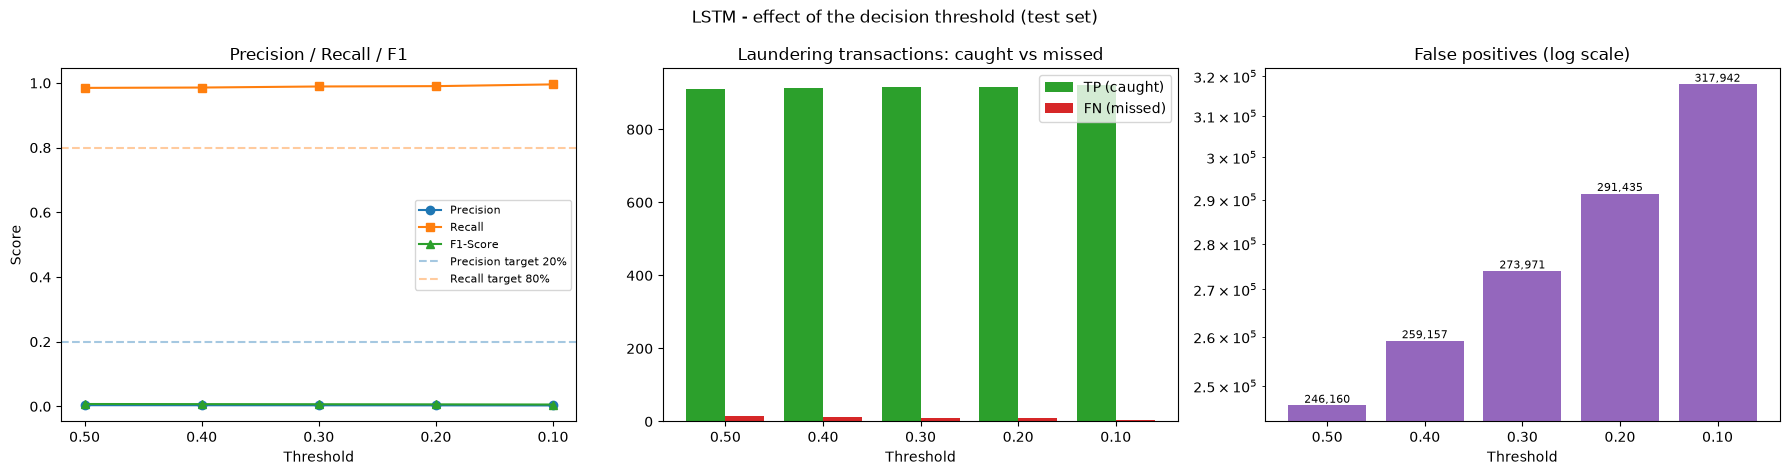

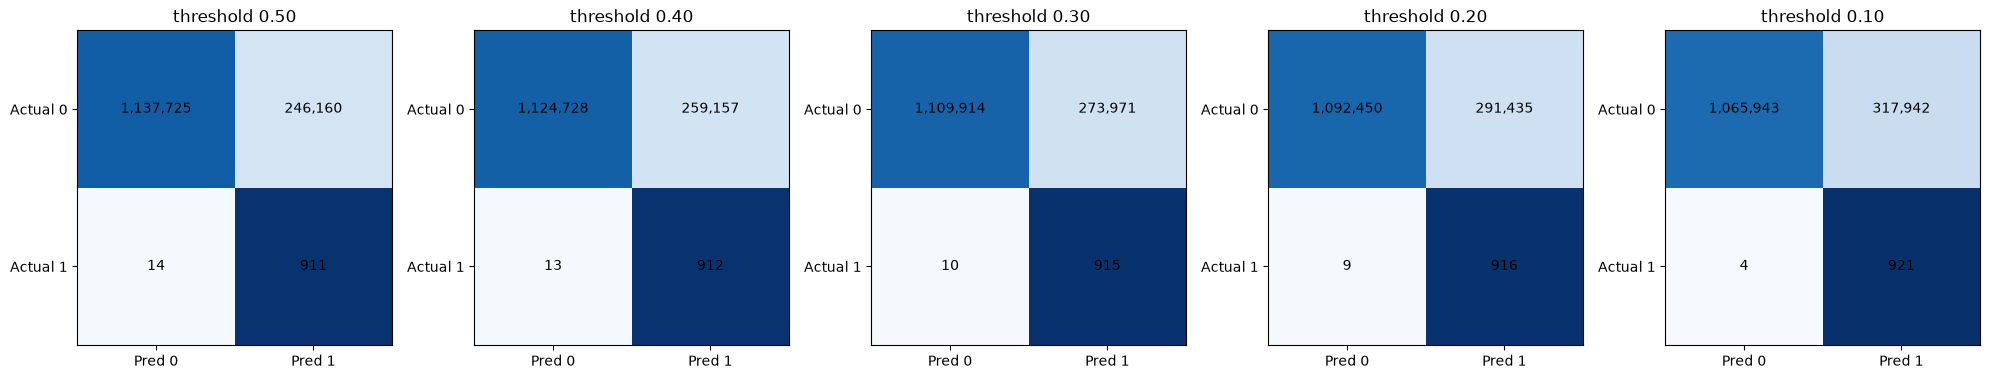

In [15]:
# ============================================================================================
# THRESHOLD STUDY (cell 3 of 4): charts comparing the five thresholds
# ============================================================================================
x = np.arange(len(thr_df)); labels = [f"{t:.2f}" for t in thr_df["Threshold"]]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
# (a) precision / recall / F1 against threshold
for col, mk in [("Precision", "o"), ("Recall", "s"), ("F1-Score", "^")]:
    axes[0].plot(labels, thr_df[col], marker=mk, label=col)
axes[0].axhline(TARGET_PRECISION, ls="--", color="tab:blue", alpha=0.4, label=f"Precision target {TARGET_PRECISION:.0%}")
axes[0].axhline(TARGET_RECALL, ls="--", color="tab:orange", alpha=0.4, label=f"Recall target {TARGET_RECALL:.0%}")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Score"); axes[0].set_title("Precision / Recall / F1"); axes[0].legend(fontsize=8)
# (b) laundering caught vs missed
axes[1].bar(x - 0.2, thr_df["TP"], 0.4, label="TP (caught)", color="tab:green")
axes[1].bar(x + 0.2, thr_df["FN"], 0.4, label="FN (missed)", color="tab:red")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels); axes[1].set_xlabel("Threshold"); axes[1].set_title("Laundering transactions: caught vs missed"); axes[1].legend()
# (c) cost of the extra recall: false positives
axes[2].bar(x, thr_df["FP"], color="tab:purple")
axes[2].set_yscale("log"); axes[2].set_xticks(x); axes[2].set_xticklabels(labels)
axes[2].set_xlabel("Threshold"); axes[2].set_title("False positives (log scale)")
for i, v in enumerate(thr_df["FP"]):
    axes[2].text(i, max(v, 1), f"{v:,}", ha="center", va="bottom", fontsize=8)
fig.suptitle(f"{MODEL_NAME} - effect of the decision threshold (test set)")
fig.tight_layout(); fig.savefig(RESULTS_DIR / f"{MODEL_SLUG}_threshold_comparison.png", dpi=150); plt.show()

# confusion matrices side by side
fig, axes = plt.subplots(1, len(thr_df), figsize=(4 * len(thr_df), 3.8))
for ax, (_, r) in zip(axes, thr_df.iterrows()):
    cm = np.array([[r["TN"], r["FP"]], [r["FN"], r["TP"]]], dtype=float)
    ax.imshow(cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None), cmap="Blues", vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{int(cm[i, j]):,}", ha="center", va="center", fontsize=10, color="black")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1]); ax.set_xticklabels(["Pred 0", "Pred 1"]); ax.set_yticklabels(["Actual 0", "Actual 1"])
    ax.set_title(f"threshold {r['Threshold']:.2f}")
fig.tight_layout(); fig.savefig(RESULTS_DIR / f"{MODEL_SLUG}_threshold_confusion_matrices.png", dpi=150); plt.show()

In [16]:
best_f1 = thr_df.loc[thr_df["F1-Score"].idxmax()]
print(f"Best F1 among the five thresholds : {best_f1['Threshold']:.2f}  (F1 {best_f1['F1-Score']:.4f}, precision {best_f1['Precision']:.4f}, recall {best_f1['Recall']:.4f})")
rec_ok = thr_df[thr_df["Recall"] >= TARGET_RECALL]
if len(rec_ok):
    hp = rec_ok.loc[rec_ok["Precision"].idxmax()]
    print(f"Recall >= {TARGET_RECALL:.0%} is reached at thresholds {list(rec_ok['Threshold'])}; best precision there: {hp['Precision']:.4f} at {hp['Threshold']:.2f}")
else:
    print(f"No threshold reaches recall >= {TARGET_RECALL:.0%} (best {thr_df['Recall'].max():.4f}).")
both = thr_df[thr_df["Meets BOTH targets?"]]
print(f"\nTARGET (precision >= {TARGET_PRECISION:.0%} AND recall >= {TARGET_RECALL:.0%}): " + (f"MET at {list(both['Threshold'])}" if len(both) else "NOT met at any of the five thresholds"))
print("The threshold only trades precision against recall; ROC-AUC / PR-AUC (ranking quality) do not change with it.")
print("These numbers are computed on the test set for description. A final operating threshold should be chosen on separate validation data.")

Best F1 among the five thresholds : 0.50  (F1 0.0073, precision 0.0037, recall 0.9849)
Recall >= 80% is reached at thresholds [0.5, 0.4, 0.3, 0.2, 0.1]; best precision there: 0.0037 at 0.50

TARGET (precision >= 20% AND recall >= 80%): NOT met at any of the five thresholds
The threshold only trades precision against recall; ROC-AUC / PR-AUC (ranking quality) do not change with it.
These numbers are computed on the test set for description. A final operating threshold should be chosen on separate validation data.


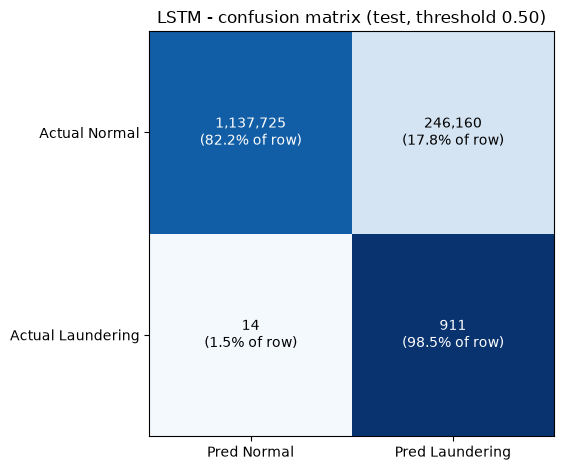

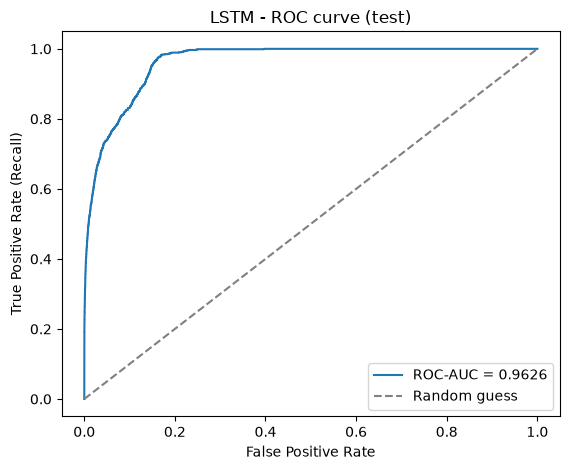

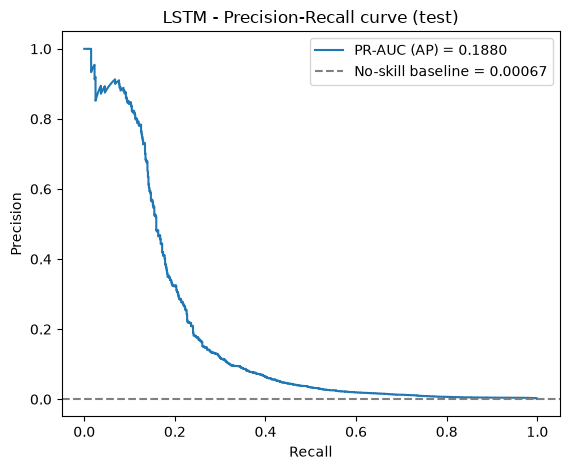

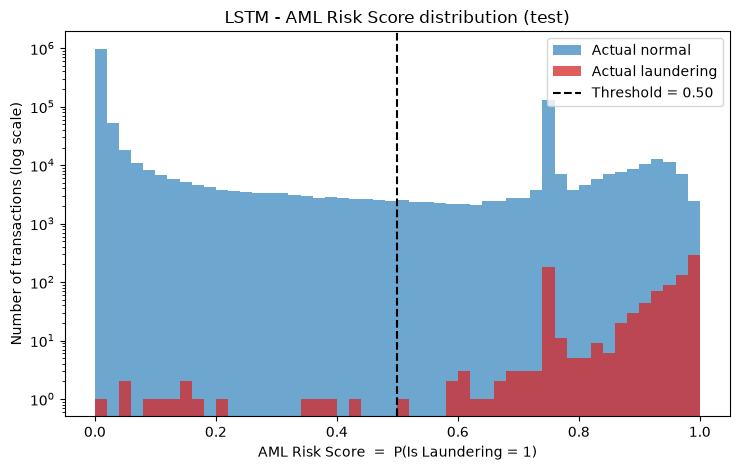

In [17]:
pred05 = (score_test >= 0.50).astype(int)
save_confusion_matrix(y_test, pred05, RESULTS_DIR / f"{MODEL_SLUG}_confusion_matrix.png", f"{MODEL_NAME} - confusion matrix (test, threshold 0.50)")
save_roc_curve(y_test, score_test, RESULTS_DIR / f"{MODEL_SLUG}_roc_curve.png", f"{MODEL_NAME} - ROC curve (test)")
save_pr_curve(y_test, score_test, RESULTS_DIR / f"{MODEL_SLUG}_pr_curve.png", f"{MODEL_NAME} - Precision-Recall curve (test)")
save_risk_distribution(y_test, score_test, RESULTS_DIR / f"{MODEL_SLUG}_risk_distribution.png", f"{MODEL_NAME} - AML Risk Score distribution (test)", 0.50)

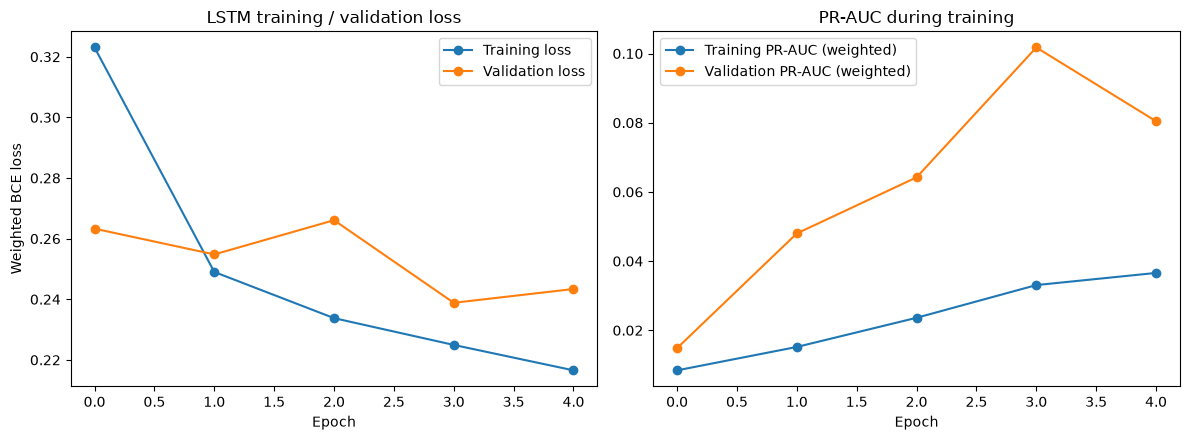

In [18]:
h = history.history
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(h["loss"], marker="o", label="Training loss"); axes[0].plot(h["val_loss"], marker="o", label="Validation loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Weighted BCE loss"); axes[0].set_title("LSTM training / validation loss"); axes[0].legend()
axes[1].plot(h.get("pr_auc", []), marker="o", label="Training PR-AUC (weighted)"); axes[1].plot(h.get("val_pr_auc", []), marker="o", label="Validation PR-AUC (weighted)")
axes[1].set_xlabel("Epoch"); axes[1].set_title("PR-AUC during training"); axes[1].legend()
fig.tight_layout(); fig.savefig(RESULTS_DIR / "lstm_training_history.png", dpi=150); plt.show()

In [19]:
MODEL_PATH = MODELS_DIR / "lstm_model.keras"
model.save(MODEL_PATH)
joblib.dump({"feature_names": FEATURE_NAMES, "cont_cols": CONT_COLS, "scaler_mean": mu, "scaler_std": sd, "payment_format_levels": fmt_levels,
             "sequence_length": SEQUENCE_LENGTH, "class_weights": CLASS_WEIGHTS}, MODELS_DIR / "lstm_preprocessing.pkl")
print("Model saved to:", MODEL_PATH)

# predictions: one row per test transaction, with the label at EVERY threshold
PRED_PATH = OUTPUTS_DIR / f"{MODEL_SLUG}_predictions.csv"
out = pred_table.copy()
for t in THRESHOLDS:
    out[f"Predicted Label @{t:.2f}"] = (score_test >= t).astype(int)
out.to_csv(PRED_PATH, index=False)

# metrics: one row per threshold
METRICS_PATH = RESULTS_DIR / f"{MODEL_SLUG}_metrics.csv"
metrics_df = thr_df.copy()
metrics_df.insert(0, "Model", MODEL_NAME)
metrics_df["Train Rows"] = len(train_idx); metrics_df["Test Rows"] = len(test_idx); metrics_df["Split Mode"] = SPLIT_MODE
metrics_df.to_csv(METRICS_PATH, index=False)
print("Predictions saved to:", PRED_PATH)
print("Metrics saved to    :", METRICS_PATH)

Model saved to: E:\AML-GNN-Project\models\lstm_model.keras
Predictions saved to: E:\AML-GNN-Project\outputs\lstm_predictions.csv
Metrics saved to    : E:\AML-GNN-Project\results\lstm_metrics.csv


In [20]:
# LI-Small_Patterns.txt is NOT a one-row-per-transaction CSV. It is a separate pattern-analysis / validation resource.
# We only inspect it here (count the pattern types). We deliberately do NOT merge it into the feature matrix and
# we do NOT invent transaction-level pattern labels.
if PATH_PATTERNS.exists():
    begin_re = re.compile(r"BEGIN LAUNDERING ATTEMPT\s*-\s*([A-Za-z0-9\-_ ]+?)\s*(?::|$)", re.I)
    pattern_counts, preview, n_lines = {}, [], 0
    with open(PATH_PATTERNS, "r", errors="ignore") as fh:
        for line in fh:
            n_lines += 1
            if len(preview) < 12:
                preview.append(line.rstrip())
            m = begin_re.search(line)
            if m:
                k = m.group(1).strip().upper()
                pattern_counts[k] = pattern_counts.get(k, 0) + 1
    print(f"Patterns file: {n_lines:,} lines")
    print("First lines:"); print("\n".join("   " + p for p in preview))
    if pattern_counts:
        print("\nLaundering-attempt blocks per pattern type:")
        display(pd.Series(pattern_counts, name="Attempts").sort_values(ascending=False).to_frame())
    else:
        print("No 'BEGIN LAUNDERING ATTEMPT' headers recognised - inspect the file format manually.")
else:
    print("Patterns file not found - skipping (it is not required for training).")

Patterns file: 1,374 lines
First lines:
   BEGIN LAUNDERING ATTEMPT - FAN-IN:  Max 3-degree Fan-In
   2022/09/01 02:38,001812,80279F810,0110,8000A94C0,10154.74,Australian Dollar,10154.74,Australian Dollar,ACH,1
   2022/09/02 14:36,022595,80279F8B0,0110,8000A94C0,5326.79,Australian Dollar,5326.79,Australian Dollar,ACH,1
   2022/09/03 14:09,001120,800E36A50,0110,8000A94C0,4634.81,Australian Dollar,4634.81,Australian Dollar,ACH,1
   END LAUNDERING ATTEMPT - FAN-IN
   
   BEGIN LAUNDERING ATTEMPT - FAN-IN:  Max 8-degree Fan-In
   2022/09/01 03:17,003671,801BF8E70,002557,8016B3750,8099.96,Euro,8099.96,Euro,ACH,1
   2022/09/01 06:27,015,80074C7E0,002557,8016B3750,10468.56,Euro,10468.56,Euro,ACH,1
   2022/09/01 10:04,002557,80107C9A0,002557,8016B3750,10270.07,Euro,10270.07,Euro,ACH,1
   2022/09/02 06:35,012,800A9B180,002557,8016B3750,15645.21,Euro,15645.21,Euro,ACH,1
   2022/09/03 09:12,021393,801271170,002557,8016B3750,14139.75,Euro,14139.75,Euro,ACH,1

Laundering-attempt blocks per pattern 

,Attempts
FAN-OUT,19
STACK,18
BIPARTITE,16
RANDOM,15
SCATTER-GATHER,13
GATHER-SCATTER,12
FAN-IN,12
CYCLE,12


In [21]:
m = thr_df[thr_df["Threshold"] == 0.50].iloc[0]
print("=" * 40); print(f"MODEL: {MODEL_NAME.upper()}"); print("=" * 40)
print(f"Split mode             : {SPLIT_MODE}")
print(f"Train samples          : {len(train_idx):,}  (laundering {int(y[train_idx].sum()):,})")
print(f"Test samples           : {len(test_idx):,}  (laundering {int(y[test_idx].sum()):,})")
print(f"Average AML Risk Score : {score_test.mean():.4f} | Highest: {score_test.max():.4f}\n")
display(thr_df.set_index("Threshold")[["TP", "FP", "FN", "TN", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]])
print("Model saved to       :", MODEL_PATH); print("Predictions saved to :", PRED_PATH); print("Metrics saved to     :", METRICS_PATH)

MODEL: LSTM
Split mode             : chronological
Train samples          : 5,539,239  (laundering 2,640)
Test samples           : 1,384,810  (laundering 925)
Average AML Risk Score : 0.1587 | Highest: 1.0000



,TP,FP,FN,TN,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Threshold,,,,,,,,,,
0.500000,911,246160,14,1137725,0.822233,0.003687,0.984865,0.007347,0.962622,0.187983
0.400000,912,259157,13,1124728,0.812848,0.003507,0.985946,0.006989,0.962622,0.187983
0.300000,915,273971,10,1109914,0.802153,0.003329,0.989189,0.006635,0.962622,0.187983
0.200000,916,291435,9,1092450,0.789542,0.003133,0.990270,0.006247,0.962622,0.187983
0.100000,921,317942,4,1065943,0.770405,0.002888,0.995676,0.005760,0.962622,0.187983


Model saved to       : E:\AML-GNN-Project\models\lstm_model.keras
Predictions saved to : E:\AML-GNN-Project\outputs\lstm_predictions.csv
Metrics saved to     : E:\AML-GNN-Project\results\lstm_metrics.csv
